In [1]:
import pandas as pd

df = pd.read_csv('silver_prices_data.csv')
df.head()

,Date,Close,High,Low,Open,Volume
0,2011-01-24,27.318001,27.459999,26.955000,27.174999,168
1,2011-01-25,26.811001,26.950001,26.565001,26.915001,77
2,2011-01-26,27.132000,27.025000,26.684999,27.025000,49
3,2011-01-27,27.045000,27.684999,27.410000,27.684999,184
4,2011-01-28,27.934000,27.950001,26.504999,26.695000,64


In [2]:
df.info()
df.describe()
df.isnull().sum()

# Convert Date
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3768 entries, 0 to 3767
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3768 non-null   object 
 1   Close   3768 non-null   float64
 2   High    3768 non-null   float64
 3   Low     3768 non-null   float64
 4   Open    3768 non-null   float64
 5   Volume  3768 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 176.8+ KB


In [3]:
from sklearn.preprocessing import StandardScaler

# Handle missing values
df.ffill(inplace=True)

# Features & target
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

print("Data Ready")

Data Ready


In [4]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np

# Split (Simple Validation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse_simple = mean_squared_error(y_test, y_pred)

print("Simple Validation MSE:", mse_simple)

# K-Fold Cross Validation
cv_scores = cross_val_score(Ridge(alpha=1.0), X, y, cv=5, scoring='neg_mean_squared_error')
mse_cv = -cv_scores.mean()

print("Cross-Validation MSE:", mse_cv)

Simple Validation MSE: 0.11341820419872445
Cross-Validation MSE: 0.04627571225504637


Alpha=0.01, MSE=0.03615643453091612
Alpha=0.1, MSE=0.036442536324456494
Alpha=1, MSE=0.04627571225504637
Alpha=10, MSE=0.08410962836257084


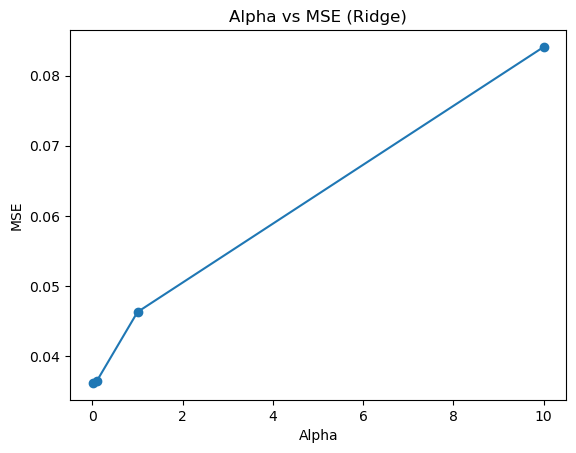

In [5]:
import matplotlib.pyplot as plt

alphas = [0.01, 0.1, 1, 10]
mse_list = []

for a in alphas:
    scores = cross_val_score(Ridge(alpha=a), X, y, cv=5, scoring='neg_mean_squared_error')
    mse_list.append(-scores.mean())

# Print results
for a, mse in zip(alphas, mse_list):
    print(f"Alpha={a}, MSE={mse}")

# Graph
plt.plot(alphas, mse_list, marker='o')
plt.xlabel("Alpha")
plt.ylabel("MSE")
plt.title("Alpha vs MSE (Ridge)")
plt.show()